# **Machine Learning Assignment :- 6**


**   **
**Name: Ghrushnesh Sudhakar Patil**

**Class: CSAI-D**     

**Batch : 3**

**Roll No: 66**

**PRN: 12411658**

**   **
Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following:

a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

b. Bivariate analysis: Linear and logistic regression modeling

c. Multiple Regression analysis

d. Also compare the results of the above analysis for the two data sets.

DATASET LINK :- [ https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database]( https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix
import statsmodels.api as sm

In [ ]:
data = pd.read_csv("diabetes.csv")
print("Original Shape:", data.shape)
data.head()

Original Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    data[col] = data[col].replace(0, np.nan)

clean_data = data.dropna()

print("Cleaned Shape:", clean_data.shape)

Cleaned Shape: (392, 9)


#




** **


#


#A. Univariate Analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

In [ ]:
print("Outcome Distribution:")
print(clean_data["Outcome"].value_counts())

Outcome Distribution:
Outcome
0    262
1    130
Name: count, dtype: int64


In [ ]:
uni_stats = pd.DataFrame()

uni_stats["Mean"] = clean_data.mean()
uni_stats["Median"] = clean_data.median()
uni_stats["Mode"] = clean_data.mode().iloc[0]
uni_stats["Variance"] = clean_data.var()
uni_stats["Std_Deviation"] = clean_data.std()
uni_stats["Skewness"] = clean_data.apply(skew)
uni_stats["Kurtosis"] = clean_data.apply(kurtosis)

print("Univariate Analysis Summary")
display(uni_stats)

Univariate Analysis Summary


,Mean,Median,Mode,Variance,Std_Deviation,Skewness,Kurtosis
Pregnancies,3.301020,2.0000,1.000,10.313247,3.211424,1.330480,1.452184
Glucose,122.627551,119.0000,100.000,952.387781,30.860781,0.515866,-0.492353
BloodPressure,70.663265,70.0000,70.000,156.152304,12.496092,-0.087181,0.770028
SkinThickness,29.145408,29.0000,32.000,110.595171,10.516424,0.208509,-0.467146
Insulin,156.056122,125.5000,105.000,14123.347226,118.841690,2.156822,6.260449
BMI,33.086224,33.2000,32.000,49.387994,7.027659,0.660944,1.521463
DiabetesPedigreeFunction,0.523046,0.4495,0.692,0.119362,0.345488,1.951597,6.270504
Age,30.864796,27.0000,22.000,104.055842,10.200777,1.398230,1.700180
Outcome,0.331633,0.0000,0.000,0.222219,0.471401,0.715240,-1.488432


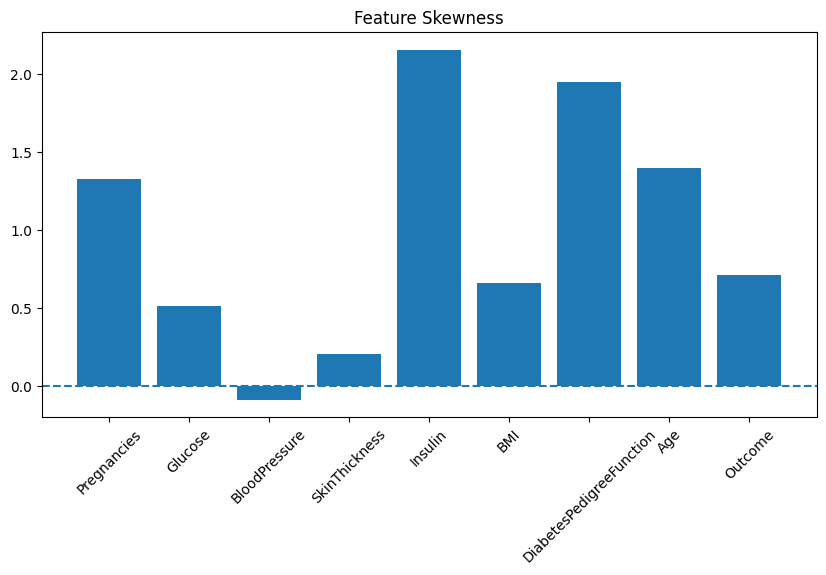

In [ ]:



plt.figure(figsize=(10,5))
plt.bar(uni_stats.index, uni_stats["Skewness"])
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--")
plt.title("Feature Skewness")
plt.show()

** **
# B. Bivariate Analysis: Linear and logistic regression modeling

In [ ]:
correlation_matrix = clean_data.corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.198291       0.213355       0.093209   
Glucose                      0.198291  1.000000       0.210027       0.198856   
BloodPressure                0.213355  0.210027       1.000000       0.232571   
SkinThickness                0.093209  0.198856       0.232571       1.000000   
Insulin                      0.078984  0.581223       0.098512       0.182199   
BMI                         -0.025347  0.209516       0.304403       0.664355   
DiabetesPedigreeFunction     0.007562  0.140180      -0.015971       0.160499   
Age                          0.679608  0.343641       0.300039       0.167761   
Outcome                      0.256566  0.515703       0.192673       0.255936   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.078984 -0.025347                  0.007562   
Glucose              

In [ ]:
X_lr = clean_data[["Glucose"]]
y_lr = clean_data["Insulin"]

X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y_lr, test_size=0.3, random_state=1
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

predictions = linear_model.predict(X_test)

print("Linear Regression Output")
print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)
print("R2 Score:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

Linear Regression Output
Slope: 2.327936397806107
Intercept: -129.91364653340716
R2 Score: 0.2272405309300114
MSE: 12603.30002639569


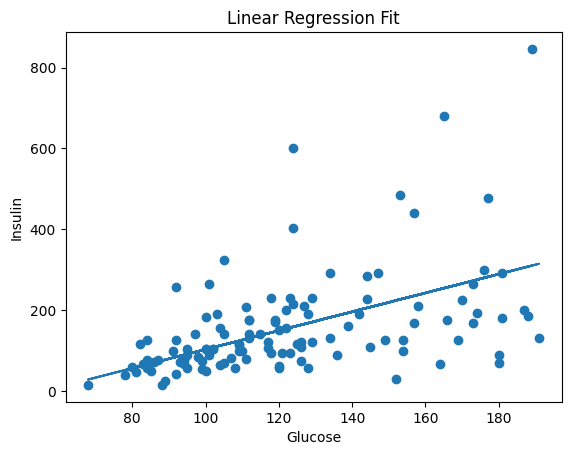

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, predictions)
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.title("Linear Regression Fit")
plt.show()

In [ ]:
X_log = clean_data.drop("Outcome", axis=1)
y_log = clean_data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.3, random_state=1
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_predictions))


Logistic Regression Results
Accuracy: 0.7542372881355932
Confusion Matrix:
 [[68 14]
 [15 21]]


** **








#

#

#



#  C. Multiple Regression Analysis



In [ ]:
X_multi = clean_data.drop("Outcome", axis=1)
y_multi = clean_data["Outcome"]

X_multi = sm.add_constant(X_multi)

multi_reg_model = sm.OLS(y_multi, X_multi).fit()

print(multi_reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Outcome   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     25.30
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.65e-31
Time:                        16:29:58   Log-Likelihood:                -177.76
No. Observations:                 392   AIC:                             373.5
Df Residuals:                     383   BIC:                             409.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

** **
#D. Also compare the results of the above analysis for the two data sets.

In [ ]:
uci_data = pd.read_csv("diabetes.csv")

print("UCI Dataset Shape:", uci_data.shape)
print("Pima Dataset Shape (Cleaned):", clean_data.shape)

if len(uci_data.columns) == len(clean_data.columns):
    print("both datasets have same features.")
else:
    print("Feature mismatch found.")

UCI Dataset Shape: (768, 9)
Pima Dataset Shape (Cleaned): (392, 9)
both datasets have same features.


In [ ]:
print("UCI Outcome Distribution:")
print(uci_clean_data["Outcome"].value_counts())

uci_uni_stats = pd.DataFrame()
uci_uni_stats["Mean"] = uci_clean_data.mean()
uci_uni_stats["Median"] = uci_clean_data.median()
uci_uni_stats["Mode"] = uci_clean_data.mode().iloc[0]
uci_uni_stats["Variance"] = uci_clean_data.var()
uci_uni_stats["Std_Deviation"] = uci_clean_data.std()
uci_uni_stats["Skewness"] = uci_clean_data.apply(skew)
uci_uni_stats["Kurtosis"] = uci_clean_data.apply(kurtosis)
print("\nUCI Univariate Analysis Summary")
display(uci_uni_stats)


UCI Outcome Distribution:
Outcome
0    262
1    130
Name: count, dtype: int64

UCI Univariate Analysis Summary


,Mean,Median,Mode,Variance,Std_Deviation,Skewness,Kurtosis
Pregnancies,3.301020,2.0000,1.000,10.313247,3.211424,1.330480,1.452184
Glucose,122.627551,119.0000,100.000,952.387781,30.860781,0.515866,-0.492353
BloodPressure,70.663265,70.0000,70.000,156.152304,12.496092,-0.087181,0.770028
SkinThickness,29.145408,29.0000,32.000,110.595171,10.516424,0.208509,-0.467146
Insulin,156.056122,125.5000,105.000,14123.347226,118.841690,2.156822,6.260449
BMI,33.086224,33.2000,32.000,49.387994,7.027659,0.660944,1.521463
DiabetesPedigreeFunction,0.523046,0.4495,0.692,0.119362,0.345488,1.951597,6.270504
Age,30.864796,27.0000,22.000,104.055842,10.200777,1.398230,1.700180
Outcome,0.331633,0.0000,0.000,0.222219,0.471401,0.715240,-1.488432


In [ ]:


uci_correlation_matrix = uci_clean_data.corr()

print("UCI Correlation Matrix:")
print(uci_correlation_matrix)

UCI Correlation Matrix:
                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.198291       0.213355       0.093209   
Glucose                      0.198291  1.000000       0.210027       0.198856   
BloodPressure                0.213355  0.210027       1.000000       0.232571   
SkinThickness                0.093209  0.198856       0.232571       1.000000   
Insulin                      0.078984  0.581223       0.098512       0.182199   
BMI                         -0.025347  0.209516       0.304403       0.664355   
DiabetesPedigreeFunction     0.007562  0.140180      -0.015971       0.160499   
Age                          0.679608  0.343641       0.300039       0.167761   
Outcome                      0.256566  0.515703       0.192673       0.255936   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.078984 -0.025347                  0.007562   
Glucose          